# Simulation Quality Comparison Results

This notebook visualizes the comparison between NegBinCopula and AE+Diffusion approaches across different numbers of highly variable genes.

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Load results from JSON file
with open('simulation_quality_comparison_results.json', 'r') as f:
    results = json.load(f)

# Extract data
n_genes = results['n_genes']
nbc_auc = results['nbc_auc']x
nbc_acc = results['nbc_acc']
ae_diff_auc = results['ae_diff_auc']
ae_diff_acc = results['ae_diff_acc']

print("Results loaded successfully!")
print(f"Number of gene configurations tested: {len(n_genes)}")
print(f"Gene counts: {n_genes}")

Results loaded successfully!
Number of gene configurations tested: 4
Gene counts: [1000, 2000, 4000, 8000]


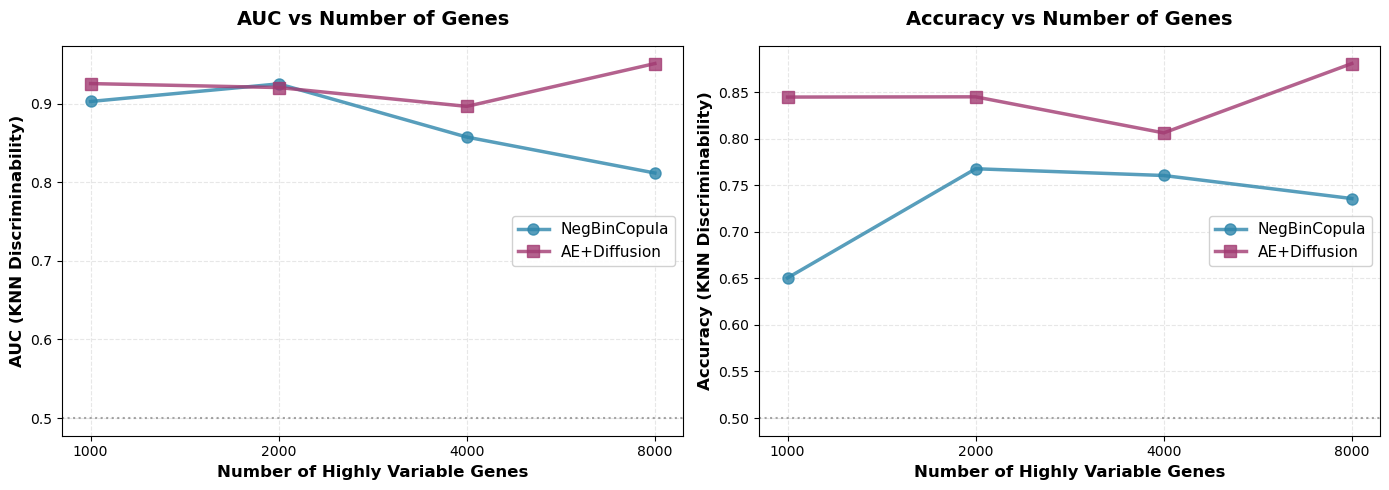


Plots saved as 'simulation_quality_comparison.png'


In [3]:
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Color scheme
nbc_color = '#2E86AB'      # Blue for NegBinCopula
ae_diff_color = '#A23B72'  # Purple/Pink for AE+Diffusion

# Plot 1: AUC vs Number of Genes
ax1.plot(n_genes, nbc_auc, marker='o', linewidth=2.5, markersize=8, 
         color=nbc_color, label='NegBinCopula', alpha=0.8)
ax1.plot(n_genes, ae_diff_auc, marker='s', linewidth=2.5, markersize=8, 
         color=ae_diff_color, label='AE+Diffusion', alpha=0.8)

ax1.set_xlabel('Number of Highly Variable Genes', fontsize=12, fontweight='bold')
ax1.set_ylabel('AUC (KNN Discriminability)', fontsize=12, fontweight='bold')
ax1.set_title('AUC vs Number of Genes', fontsize=14, fontweight='bold', pad=15)
ax1.legend(fontsize=11, framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xscale('log', base=2)
ax1.set_xticks(n_genes)
ax1.set_xticklabels(n_genes)

# Add horizontal line at 0.5 (random chance)
ax1.axhline(y=0.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label='Random (0.5)')

# Plot 2: Accuracy vs Number of Genes
ax2.plot(n_genes, nbc_acc, marker='o', linewidth=2.5, markersize=8, 
         color=nbc_color, label='NegBinCopula', alpha=0.8)
ax2.plot(n_genes, ae_diff_acc, marker='s', linewidth=2.5, markersize=8, 
         color=ae_diff_color, label='AE+Diffusion', alpha=0.8)

ax2.set_xlabel('Number of Highly Variable Genes', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (KNN Discriminability)', fontsize=12, fontweight='bold')
ax2.set_title('Accuracy vs Number of Genes', fontsize=14, fontweight='bold', pad=15)
ax2.legend(fontsize=11, framealpha=0.9)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xscale('log', base=2)
ax2.set_xticks(n_genes)
ax2.set_xticklabels(n_genes)

# Add horizontal line at 0.5 (random chance)
ax2.axhline(y=0.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label='Random (0.5)')

plt.tight_layout()
plt.savefig('simulation_quality_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlots saved as 'simulation_quality_comparison.png'")

## Interpretation

**Lower discriminability scores indicate better simulation quality** (harder to distinguish real from synthetic data).

- **AUC = 0.5 / Accuracy = 0.5**: Perfect simulation (indistinguishable from real data)
- **AUC = 1.0 / Accuracy = 1.0**: Poor simulation (easily distinguishable from real data)

The plots show how simulation quality changes as we increase the number of highly variable genes used in the analysis.

In [4]:
# Print summary statistics
print("="*70)
print("SUMMARY STATISTICS")
print("="*70)
print("\nNegBinCopula:")
print(f"  AUC - Mean: {np.mean(nbc_auc):.4f}, Std: {np.std(nbc_auc):.4f}")
print(f"  Acc - Mean: {np.mean(nbc_acc):.4f}, Std: {np.std(nbc_acc):.4f}")
print(f"  Best AUC: {min(nbc_auc):.4f} at {n_genes[np.argmin(nbc_auc)]} genes")
print(f"  Best Acc: {min(nbc_acc):.4f} at {n_genes[np.argmin(nbc_acc)]} genes")

print("\nAE+Diffusion:")
print(f"  AUC - Mean: {np.mean(ae_diff_auc):.4f}, Std: {np.std(ae_diff_auc):.4f}")
print(f"  Acc - Mean: {np.mean(ae_diff_acc):.4f}, Std: {np.std(ae_diff_acc):.4f}")
print(f"  Best AUC: {min(ae_diff_auc):.4f} at {n_genes[np.argmin(ae_diff_auc)]} genes")
print(f"  Best Acc: {min(ae_diff_acc):.4f} at {n_genes[np.argmin(ae_diff_acc)]} genes")

print("\n" + "="*70)

SUMMARY STATISTICS

NegBinCopula:
  AUC - Mean: 0.8745, Std: 0.0436
  Acc - Mean: 0.7286, Std: 0.0466
  Best AUC: 0.8119 at 8000 genes
  Best Acc: 0.6505 at 1000 genes

AE+Diffusion:
  AUC - Mean: 0.9236, Std: 0.0194
  Acc - Mean: 0.8442, Std: 0.0263
  Best AUC: 0.8968 at 4000 genes
  Best Acc: 0.8063 at 4000 genes



In [5]:
# Create a detailed comparison table
import pandas as pd

df = pd.DataFrame({
    'N_Genes': n_genes,
    'NegBinCopula_AUC': nbc_auc,
    'NegBinCopula_Acc': nbc_acc,
    'AE+Diffusion_AUC': ae_diff_auc,
    'AE+Diffusion_Acc': ae_diff_acc,
    'AUC_Diff': [ae - nb for ae, nb in zip(ae_diff_auc, nbc_auc)],
    'Acc_Diff': [ae - nb for ae, nb in zip(ae_diff_acc, nbc_acc)]
})

print("\nDetailed Comparison Table:")
print("(Positive Diff means AE+Diffusion has higher discriminability = worse quality)")
print(df.to_string(index=False))


Detailed Comparison Table:
(Positive Diff means AE+Diffusion has higher discriminability = worse quality)
 N_Genes  NegBinCopula_AUC  NegBinCopula_Acc  AE+Diffusion_AUC  AE+Diffusion_Acc  AUC_Diff  Acc_Diff
    1000          0.903017           0.65050          0.925795           0.84475  0.022778   0.19425
    2000          0.925405           0.76775          0.920747           0.84500 -0.004658   0.07725
    4000          0.857686           0.76050          0.896769           0.80625  0.039083   0.04575
    8000          0.811939           0.73575          0.951287           0.88075  0.139348   0.14500


In [6]:
df

,N_Genes,NegBinCopula_AUC,NegBinCopula_Acc,AE+Diffusion_AUC,AE+Diffusion_Acc,AUC_Diff,Acc_Diff
0,1000,0.903017,0.65050,0.925795,0.84475,0.022778,0.19425
1,2000,0.925405,0.76775,0.920747,0.84500,-0.004658,0.07725
2,4000,0.857686,0.76050,0.896769,0.80625,0.039083,0.04575
3,8000,0.811939,0.73575,0.951287,0.88075,0.139348,0.14500
